In [7]:
import numpy as np
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from tqdm.notebook import tqdm


from modulars.plot_rr import plot_a_few_trajectories_1d, plot_mean_band_rrs_1d
from modulars.utils import load_config, load_best_values, exp_lognormal_moments
from modulars.distributions import gaussian_1d

In [8]:
config_file = '../invgamma_config.json'
config = load_config(config_file)
mu_like = config['mu_like']
sigma_like = config['sigma_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']
max_iters = 100_000#config['max_iters']
adam_step = 5e-4#config['adam_step']

DATA = True
if DATA:
  data = gaussian_1d(n_samples, mu_like, sigma_like=sigma_like).astype(np.float32)
else:
  data = []

In [9]:
def model(y):
    sigmasq = numpyro.sample("sigma_sq", dist.InverseGamma(alpha_prior, beta_prior))
    numpyro.sample('y', dist.Normal(mu_like, jnp.sqrt(sigmasq)), obs=y)

from modulars import run_restart_1d
results = []
for seed in tqdm(range(100)):
    result = run_restart_1d(seed, model, data, 'sigma_sq', 100_000, n_particles=100)
    results.append(result)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

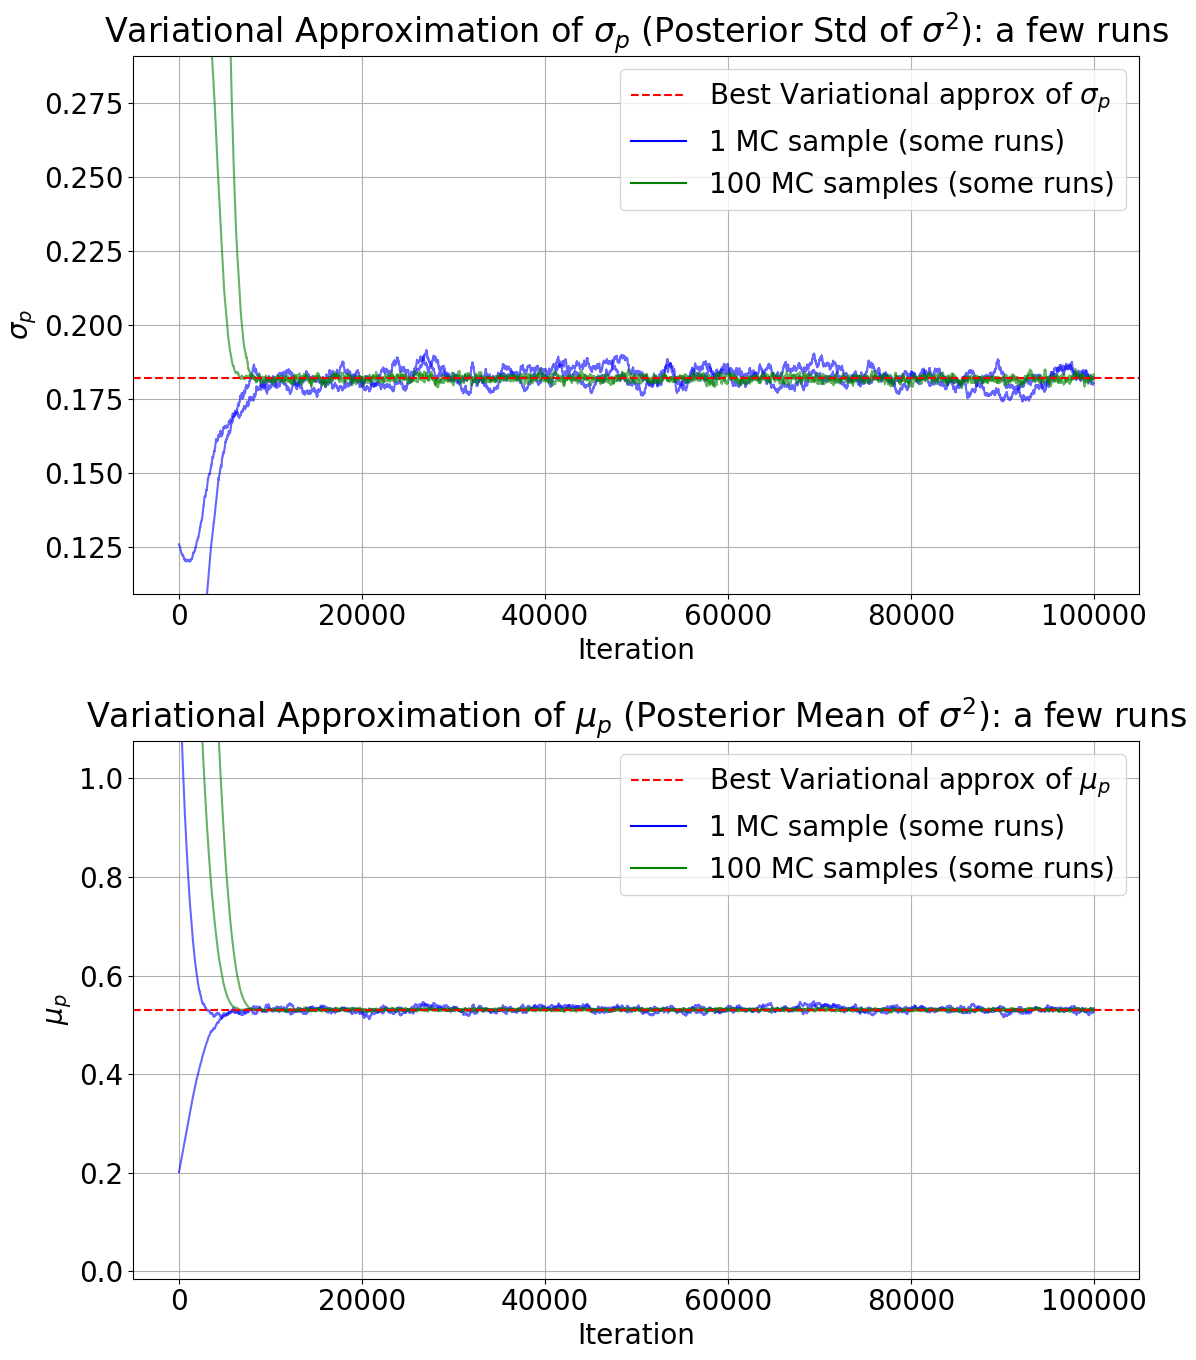

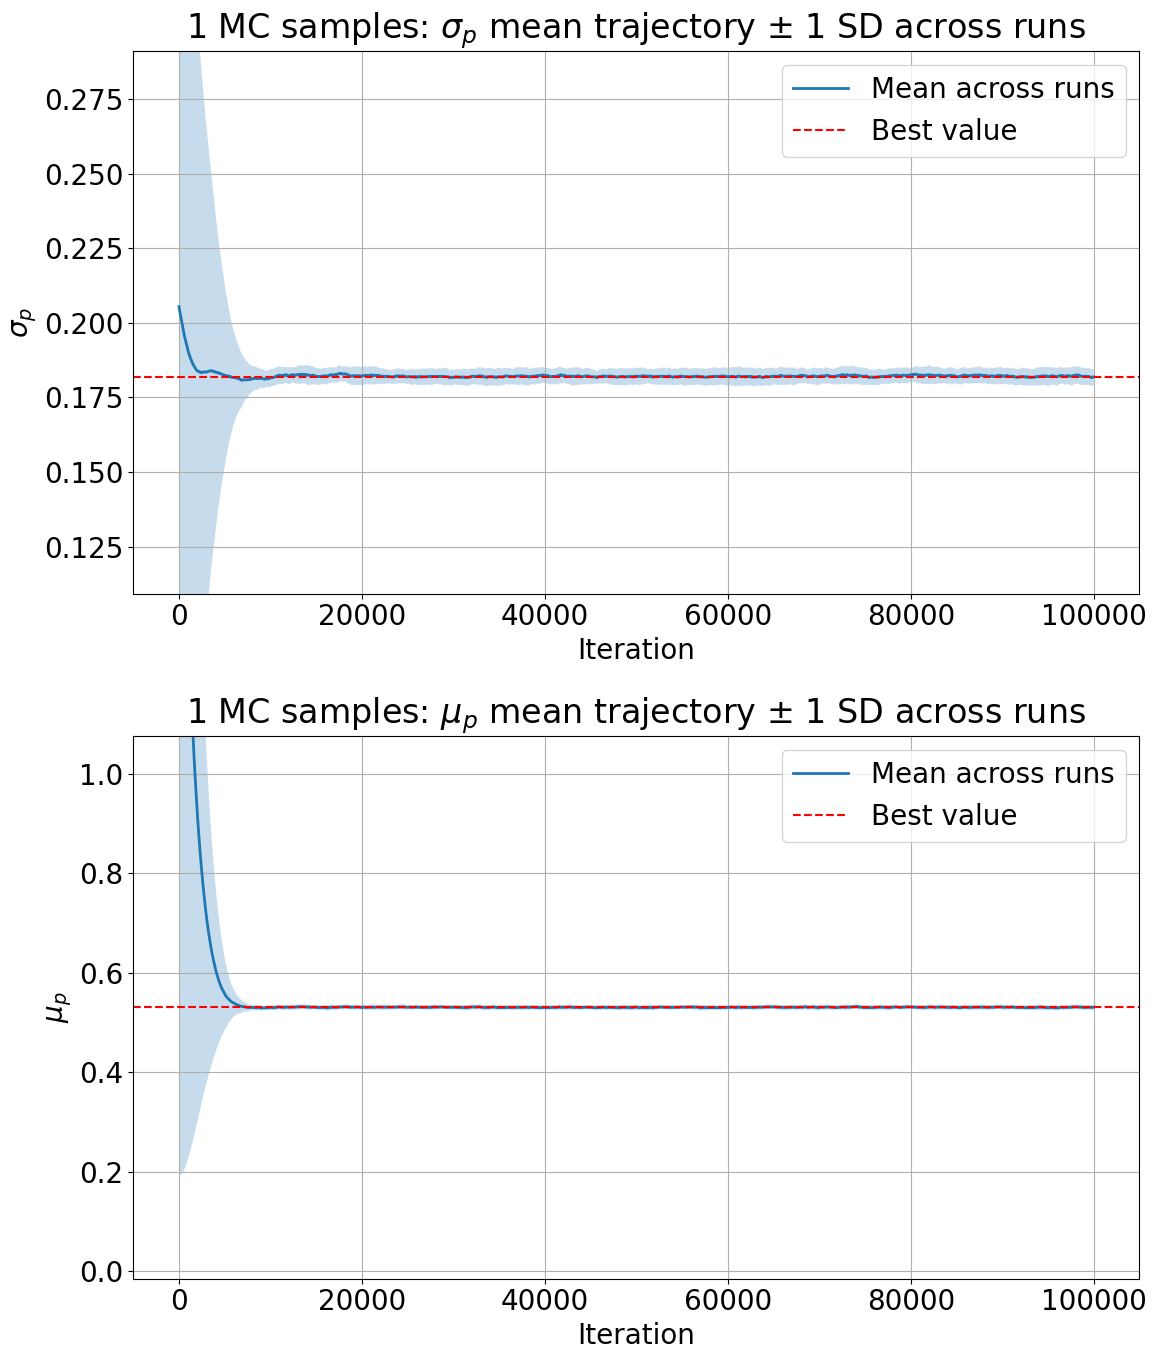

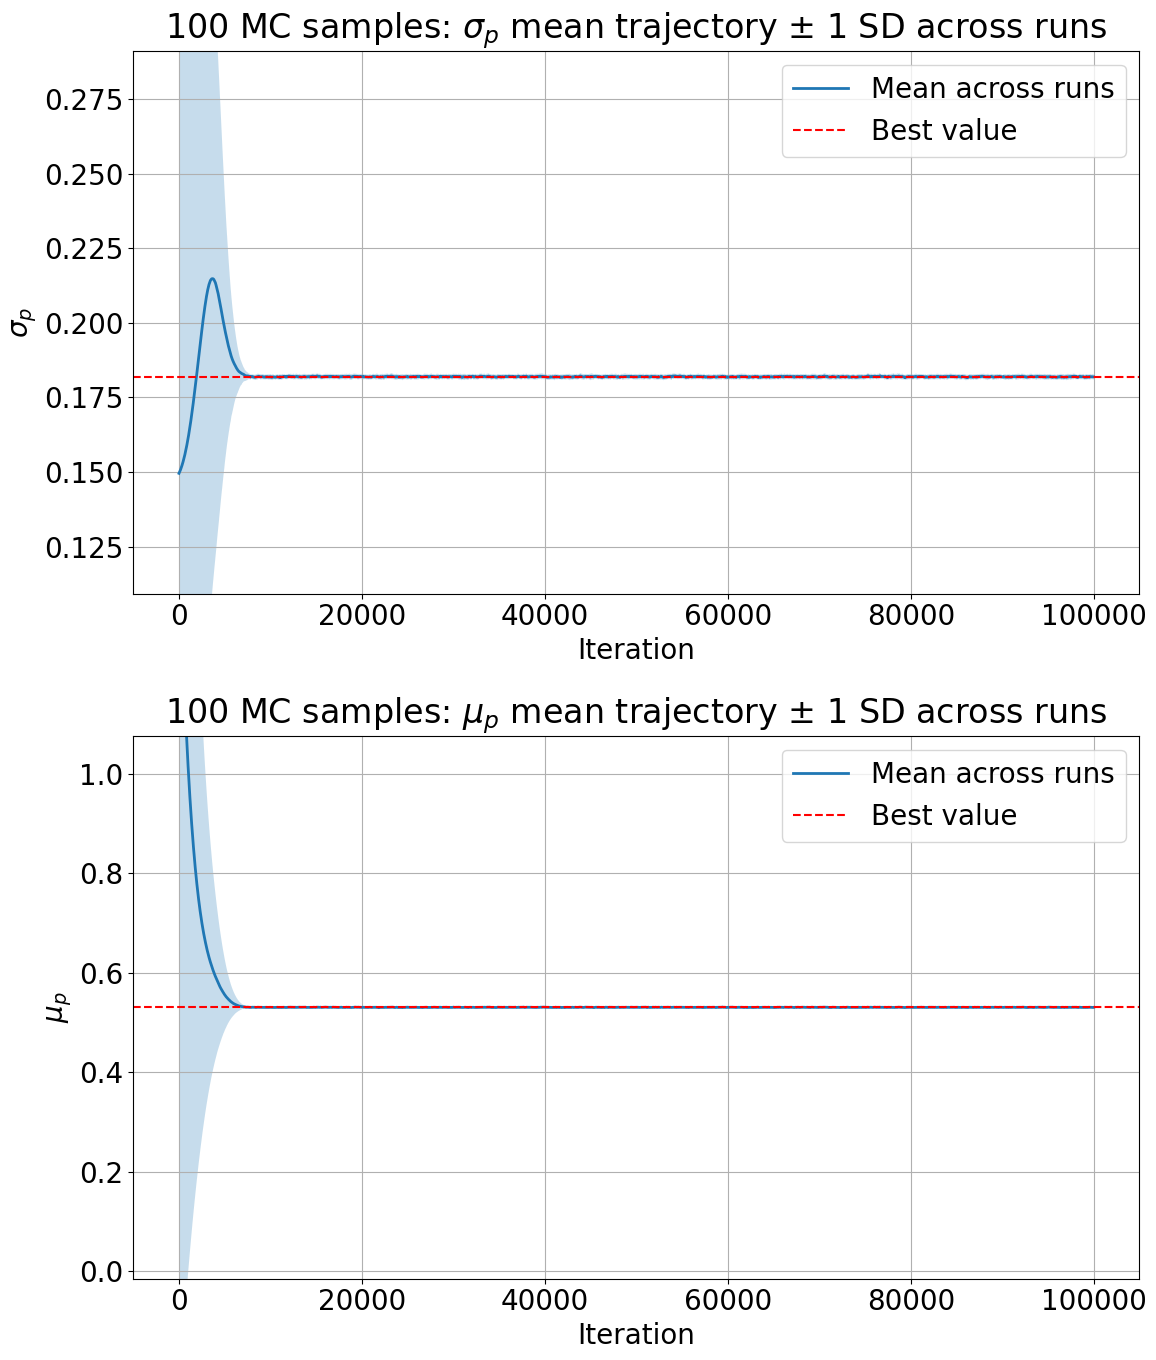

In [11]:
from modulars import apply_traj_transform
single_means, single_stds, multi_means, multi_stds = \
apply_traj_transform(results, transform_fn=exp_lognormal_moments, n_samples=10_000, seed=1, NOTEBOOK=True)
N, T = single_means.shape
x = np.arange(T)
# If we have "best" from config, these should be on theta-scale (0,1)
best_mu, best_std = load_best_values(
    config=config, transform=exp_lognormal_moments,
    n_samples=50_000, seed=1)

plot_a_few_trajectories_1d(
    [single_means, single_stds], [multi_means, multi_stds],
    best_mu, best_std, r'$\sigma^2$')
plot_mean_band_rrs_1d(
    single_means, single_stds, best_mu, best_std,
    x, r'$\sigma^2$', 1)
plot_mean_band_rrs_1d(
    multi_means, multi_stds, best_mu, best_std,
    x, r'$\sigma^2$', 100)